# GSM vs Haslam vs Guzman at 45 MHz

Verify that the GSM 2016 at 45 MHz is more similar to the
Guzman 45 MHz map than the Haslam 408 MHz map scaled by a power law.

In [1]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from pygdsm import GlobalSkyModel16
from scipy.ndimage import map_coordinates

%matplotlib widget

## 1. Load Maps

In [2]:
# --- Guzman 45 MHz (CAR projection in Galactic coords) ---
hdul = fits.open("wlb45.fits")
guz_car = hdul[0].data.astype(np.float64)
hdr = hdul[0].header
hdul.close()

# CAR grid: GLON and GLAT
nlon, nlat = hdr["NAXIS1"], hdr["NAXIS2"]
glon = hdr["CRVAL1"] + hdr["CDELT1"] * (np.arange(nlon) - (hdr["CRPIX1"] - 1))
glat = hdr["CRVAL2"] + hdr["CDELT2"] * (np.arange(nlat) - (hdr["CRPIX2"] - 1))
print(f"Guzman CAR: {nlat} x {nlon}, "
      f"GLON [{glon[0]:.1f}, {glon[-1]:.1f}], "
      f"GLAT [{glat[0]:.1f}, {glat[-1]:.1f}]")

# Reproject to HEALPix nside=64 (Galactic frame)
nside = 64
npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix))
hp_glat = 90.0 - np.degrees(theta)   # colatitude -> latitude
hp_glon = np.degrees(phi)             # already in [0, 360)

# Bilinear interpolation from CAR grid
row = (hp_glat - glat[0]) / (glat[1] - glat[0])
col = (hp_glon - glon[0]) / (glon[1] - glon[0])
# Wrap longitude
col = col % nlon

guzman = map_coordinates(
    guz_car, [row, col], order=1, mode="wrap",
)
print(f"Guzman HEALPix: nside={nside}, "
      f"min={guzman.min():.0f}, max={guzman.max():.0f} K")

Guzman CAR: 721 x 1441, GLON [180.0, -180.0], GLAT [-90.0, 90.0]
Guzman HEALPix: nside=64, min=3272, max=69595 K


In [3]:
# --- Haslam 408 MHz scaled to 45 MHz ---
haslam_raw = hp.read_map(
    "../data/20260215_for_christian/haslam408_ds_Remazeilles2014.fits"
)
haslam_64 = hp.ud_grade(haslam_raw, nside)
beta = -2.55
T_CMB = 2.725
haslam_45 = (haslam_64 - T_CMB) * (45.0 / 408.0) ** beta + T_CMB
print(f"Haslam scaled to 45 MHz: "
      f"min={haslam_45.min():.0f}, max={haslam_45.max():.0f} K")

# --- GSM 2016 at 45 MHz ---
gsm = GlobalSkyModel16(
    freq_unit="MHz", data_unit="TRJ",
    resolution="low", include_cmb=True,
)
gsm_45 = gsm.generate(45.0)
gsm_45 = hp.ud_grade(gsm_45, nside)
print(f"GSM at 45 MHz: "
      f"min={gsm_45.min():.0f}, max={gsm_45.max():.0f} K")

Haslam scaled to 45 MHz: min=2704, max=625689 K
GSM at 45 MHz: min=3409, max=56030 K


## 2. Declination Mask

The Guzman survey was conducted from Chile and has limited
coverage above declination $\sim 65^\circ$. Mask those pixels
so we only compare where Guzman has reliable data.

In [4]:
from astropy.coordinates import Galactic, ICRS
import astropy.units as u

# Convert HEALPix Galactic coords to equatorial declination
gal = Galactic(l=hp_glon * u.deg, b=hp_glat * u.deg)
eq = gal.transform_to(ICRS())
dec = eq.dec.deg

dec_max = 65.0
mask = dec < dec_max
print(f"Masking dec > {dec_max} deg")
print(f"Valid pixels: {mask.sum()} / {npix} "
      f"({100 * mask.sum() / npix:.0f}%)")

Masking dec > 65.0 deg
Valid pixels: 46845 / 49152 (95%)


## 3. Comparison

In [5]:
def rms_residual(ref, comp, mask):
    """Fractional RMS of (comp - ref) / ref."""
    frac = (comp[mask] - ref[mask]) / ref[mask]
    return np.sqrt(np.mean(frac**2))

def rms_absolute(ref, comp, mask):
    """RMS of (comp - ref) in Kelvin."""
    return np.sqrt(np.mean((comp[mask] - ref[mask])**2))

print("Fractional RMS residual (Guzman as reference):")
print(f"  Haslam vs Guzman: {rms_residual(guzman, haslam_45, mask):.3f}")
print(f"  GSM    vs Guzman: {rms_residual(guzman, gsm_45, mask):.3f}")
print()
print("Absolute RMS residual [K]:")
print(f"  Haslam vs Guzman: {rms_absolute(guzman, haslam_45, mask):.0f} K")
print(f"  GSM    vs Guzman: {rms_absolute(guzman, gsm_45, mask):.0f} K")
print()
print("For reference (no mask):")
print(f"  Haslam vs Guzman: {rms_residual(guzman, haslam_45, np.ones(npix, bool)):.3f}")
print(f"  GSM    vs Guzman: {rms_residual(guzman, gsm_45, np.ones(npix, bool)):.3f}")

Fractional RMS residual (Guzman as reference):
  Haslam vs Guzman: 0.241
  GSM    vs Guzman: 0.071

Absolute RMS residual [K]:
  Haslam vs Guzman: 6668 K
  GSM    vs Guzman: 842 K

For reference (no mask):
  Haslam vs Guzman: 0.300
  GSM    vs Guzman: 0.215


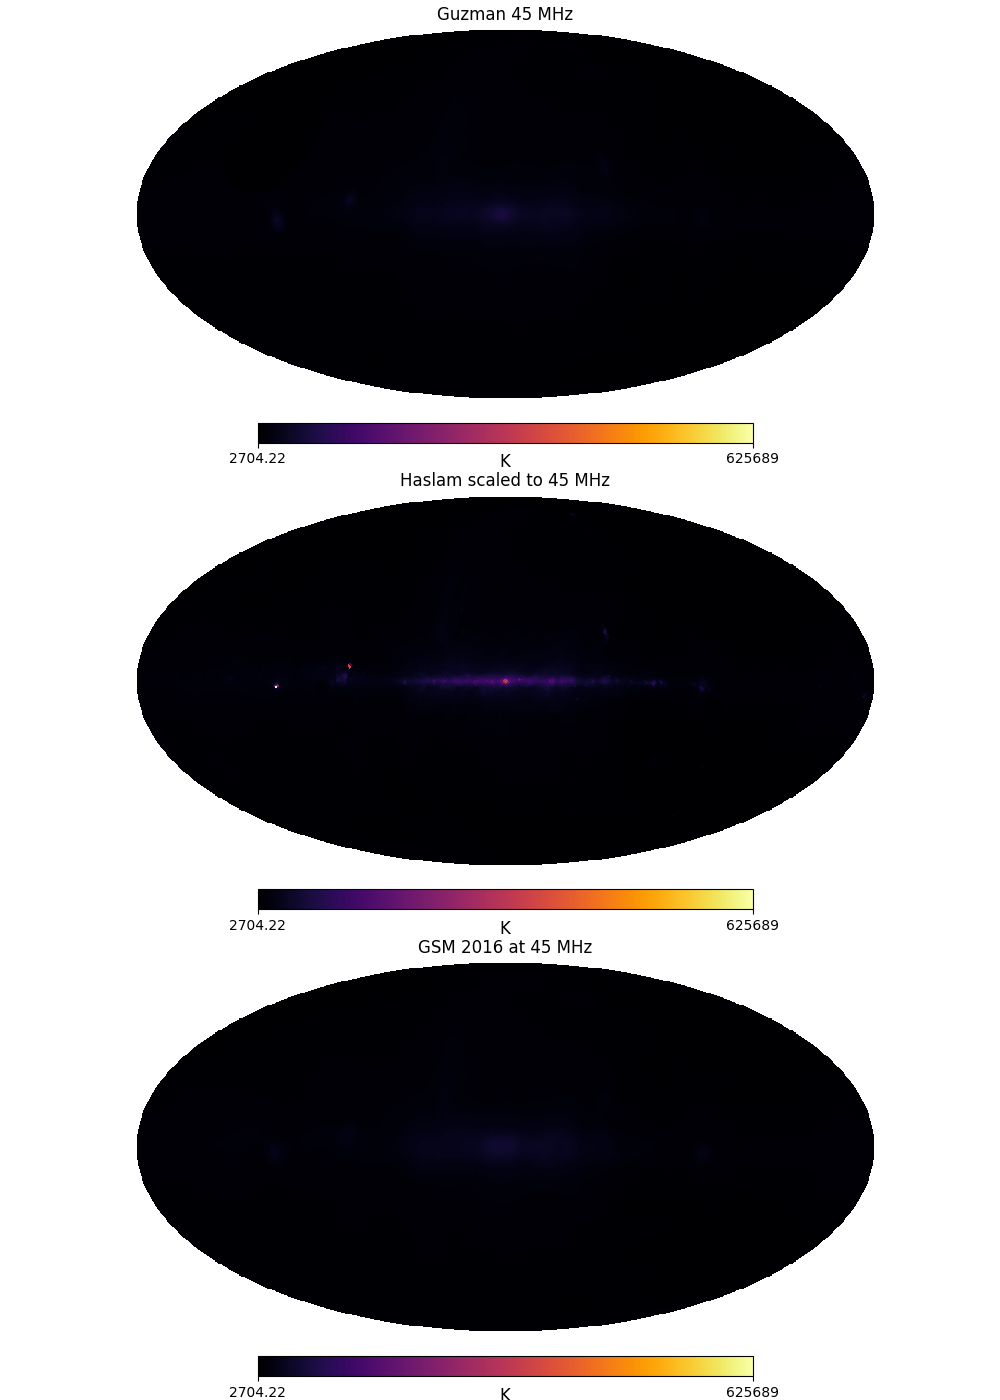

In [6]:
fig = plt.figure(figsize=(10, 14))

vmin = min(guzman[mask].min(), haslam_45[mask].min(), gsm_45[mask].min())
vmax = max(guzman[mask].max(), haslam_45[mask].max(), gsm_45[mask].max())

for i, (m, title) in enumerate([
    (guzman, "Guzman 45 MHz"),
    (haslam_45, "Haslam scaled to 45 MHz"),
    (gsm_45, "GSM 2016 at 45 MHz"),
]):
    hp.mollview(
        m, sub=(3, 1, i + 1), title=title,
        cmap="inferno", min=vmin, max=vmax,
        unit="K", cbar=True,
    )

plt.show()

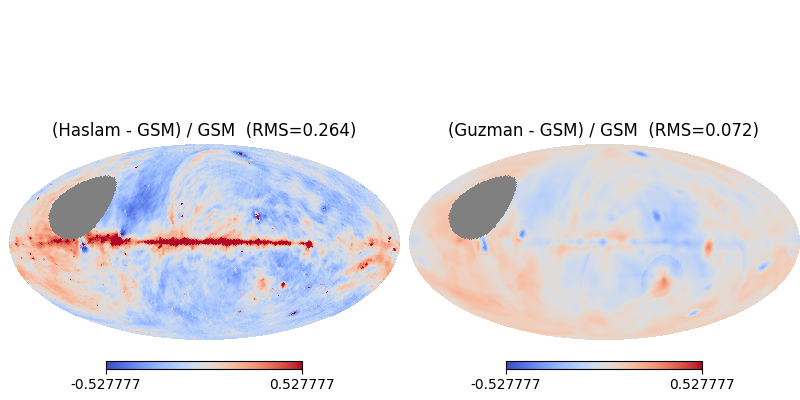

In [14]:
# Fractional residual maps
frac_haslam = np.full(npix, hp.UNSEEN)
frac_gsm = np.full(npix, hp.UNSEEN)
frac_haslam[mask] = (haslam_45[mask] - guzman[mask]) / guzman[mask]
frac_gsm[mask] = (gsm_45[mask] - guzman[mask]) / guzman[mask]

rms_h = rms_residual(gsm_45, haslam_45, mask)
rms_g = rms_residual(gsm_45, guzman, mask)

fig = plt.figure(figsize=(8, 4))
frac_range = max(rms_h, rms_g) * 2

hp.mollview(
    frac_haslam, sub=(1, 2, 1),
    title=f"(Haslam - GSM) / GSM  (RMS={rms_h:.3f})",
    cmap="coolwarm", min=-frac_range, max=frac_range,
    cbar=True,
)
hp.mollview(
    frac_gsm, sub=(1, 2, 2),
    title=f"(Guzman - GSM) / GSM  (RMS={rms_g:.3f})",
    cmap="coolwarm", min=-frac_range, max=frac_range,
    cbar=True,
)

plt.show()

In [ ]:
# Power spectrum comparison
cl_guz = hp.anafast(guzman, lmax=30)
cl_has = hp.anafast(haslam_45, lmax=30)
cl_gsm = hp.anafast(gsm_45, lmax=30)
ell = np.arange(len(cl_guz))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5), constrained_layout=True,
)

ax1.semilogy(ell, cl_guz, "k-", lw=2, label="Guzman 45 MHz")
ax1.semilogy(ell, cl_has, "C0-", lw=1.5, label="Haslam scaled")
ax1.semilogy(ell, cl_gsm, "C1--", lw=1.5, label="GSM 2016")
ax1.set_xlabel(r"$\ell$", fontsize=14)
ax1.set_ylabel(r"$C_\ell$ [K$^2$]", fontsize=14)
ax1.set_title("Power Spectra at 45 MHz")
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Ratio to Guzman
valid = cl_guz > 0
ax2.plot(ell[valid], cl_has[valid] / cl_guz[valid],
         "C0-", lw=1.5, label="Haslam / Guzman")
ax2.plot(ell[valid], cl_gsm[valid] / cl_guz[valid],
         "C1--", lw=1.5, label="GSM / Guzman")
ax2.axhline(1, color="k", ls="--", alpha=0.5)
ax2.set_xlabel(r"$\ell$", fontsize=14)
ax2.set_ylabel("Ratio to Guzman", fontsize=14)
ax2.set_title(r"$C_\ell$ Ratio")
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.show()